In [23]:
library(tidyverse)

visit_data <- read_csv("data/preprocessed_visits_data_20240701-20260211.csv")

Rows: 127656 Columns: 5
── Column specification ─────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): Branch, Reason
dbl  (1): Visits
lgl  (1): ScheduledOpen
dttm (1): Datetime

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


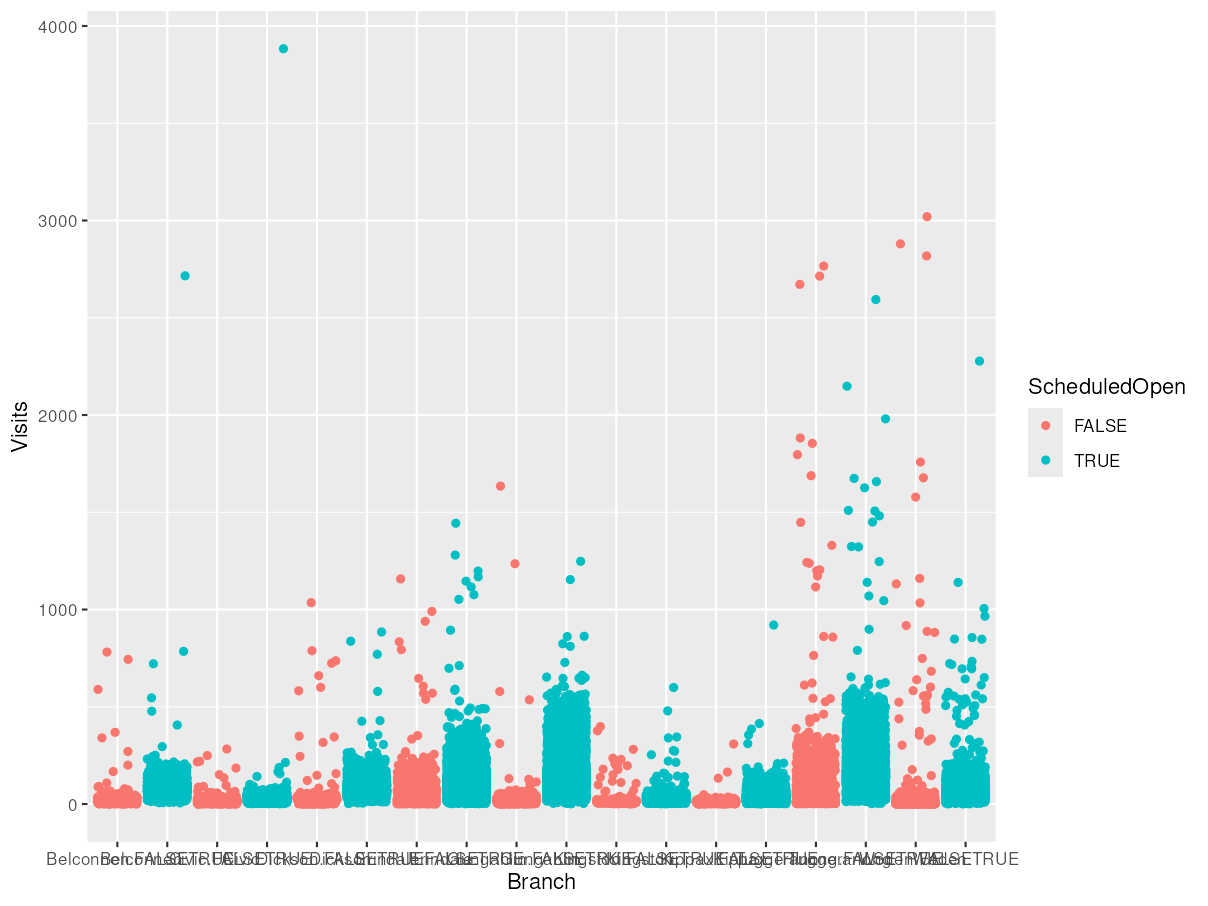

In [24]:
visit_data |> 
  filter(Visits > 0) |> 
  mutate(BranchFacets = interaction(Branch, ScheduledOpen, lex.order = TRUE)) |> 
  ggplot(
    aes(
      y = Visits,
      x = BranchFacets,
      colour = ScheduledOpen
    )
  ) +
    geom_point(position = "jitter") +
    labs(x = "Branch")

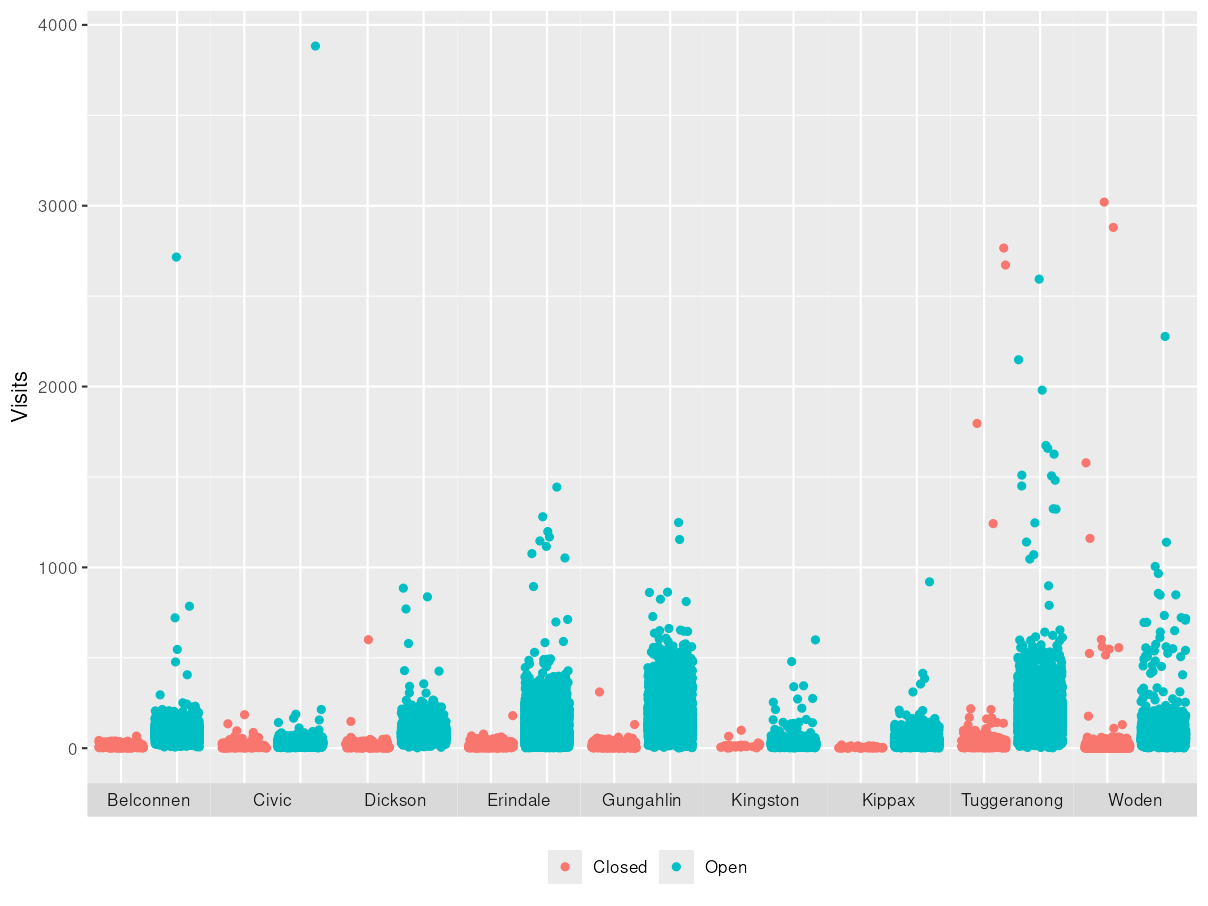

In [ ]:
visit_data |> 
  filter(Visits > 0 & format(Datetime, "%H") != "09") |> 
  ggplot(
    aes(
      y = Visits,
      x = ScheduledOpen,
      colour = ScheduledOpen
    )
  ) +
  geom_point(position = position_jitter(height = 0)) +
  facet_grid(. ~ Branch, switch = "x") +
  scale_y_continuous() +
  scale_colour_discrete(
    name = "",
    labels = c(
      `FALSE` = "Closed",
      `TRUE` = "Open"
    )
  ) +
  theme(
    strip.placement = "inside",
    panel.spacing = unit(0, "pt"),
    axis.title.x = element_blank(),
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank()
  ) +
    guides(colour = guide_legend(position = "bottom"))

In [30]:
visit_data |> mutate(Hour = format(Datetime, "%H"))

# A tibble: 127,656 × 6
   Branch      Datetime            Visits ScheduledOpen Reason              Hour 
   <chr>       <dttm>               <dbl> <lgl>         <chr>               <chr>
 1 Belconnen   2024-07-01 00:00:00      0 FALSE         NA                  00   
 2 Civic       2024-07-01 00:00:00      0 FALSE         NA                  00   
 3 Dickson     2024-07-01 00:00:00      0 FALSE         NA                  00   
 4 Erindale    2024-07-01 00:00:00      0 FALSE         NA                  00   
 5 Gungahlin   2024-07-01 00:00:00      0 FALSE         NA                  00   
 6 Kingston    2024-07-01 00:00:00      0 FALSE         NA                  00   
 7 Kippax      2024-07-01 00:00:00      0 FALSE         NA                  00   
 8 Tuggeranong 2024-07-01 00:00:00      0 FALSE         NA                  00   
 9 Woden       2024-07-01 00:00:00      0 FALSE         Major upgrade works 00   
10 Belconnen   2024-07-01 01:00:00      0 FALSE         NA                